In [50]:
#First of all imported libraries pandas and numpy for mathematical operations and yfinance for data scraping
import yfinance as yf
import pandas as pd
import numpy as np

# I choose Apple, google and microsoft stocks. 
tickers = ["AAPL", "GOOGL", "MSFT"]
# datas between 2018 to 2024
data = yf.download(tickers, start="2018-01-01", end="2024-01-01")
# also their change percentage
returns = data.pct_change(fill_method=None).dropna()


[*********************100%***********************]  3 of 3 completed


In [51]:
data.head()

Price           Close                             High                        \
Ticker           AAPL      GOOGL       MSFT       AAPL      GOOGL       MSFT   
Date                                                                           
2018-01-02  40.479839  53.466679  79.633499  40.489241  53.604679  79.967043   
2018-01-03  40.472778  54.378876  80.004135  41.017963  54.607049  80.152380   
2018-01-04  40.660778  54.590103  80.708260  40.764175  55.004601  81.217843   
2018-01-05  41.123714  55.313984  81.708900  41.210661  55.477891  81.912734   
2018-01-08  40.970970  55.509274  81.792282  41.267060  55.755881  82.070238   

Price             Low                             Open                        \
Ticker           AAPL      GOOGL       MSFT       AAPL      GOOGL       MSFT   
Date                                                                           
2018-01-02  39.774861  52.460826  79.216573  39.986357  52.460826  79.800271   
2018-01-03  40.409333  53.477644  79.652064  40.543277  53.502551  79.735446   
2018-01-04  40.437536  54.515377  80.207944  40.545630  54.656365  80.226471   
2018-01-05  40.665479  54.891018  81.004751  40.757126  54.973220  81.217851   
2018-01-08  40.872270  55.299535  81.162255  40.970970  55.349354  81.718160   

Price          Volume                      
Ticker           AAPL     GOOGL      MSFT  
Date                                       
2018-01-02  102223600  31766000  22483800  
2018-01-03  118071600  31318000  26061400  
2018-01-04   89738400  26052000  21912000  
2018-01-05   94640000  30250000  23407100  
2018-01-08   82271200  24644000  22113000

In [52]:
# dropped high, low and open price columns , because they dont matter for our model
data= data.drop(columns= ["High","Low","Open"])

In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1509 entries, 2018-01-02 to 2023-12-29
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    1509 non-null   float64
 1   (Close, GOOGL)   1509 non-null   float64
 2   (Close, MSFT)    1509 non-null   float64
 3   (Volume, AAPL)   1509 non-null   int64  
 4   (Volume, GOOGL)  1509 non-null   int64  
 5   (Volume, MSFT)   1509 non-null   int64  
dtypes: float64(3), int64(3)
memory usage: 82.5 KB


In [54]:
# I convert volume datas from int data type to float data type, because i want to same data type for all datas.
data["Volume"]=data["Volume"].astype(float)

In [55]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1509 entries, 2018-01-02 to 2023-12-29
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    1509 non-null   float64
 1   (Close, GOOGL)   1509 non-null   float64
 2   (Close, MSFT)    1509 non-null   float64
 3   (Volume, AAPL)   1509 non-null   float64
 4   (Volume, GOOGL)  1509 non-null   float64
 5   (Volume, MSFT)   1509 non-null   float64
dtypes: float64(6)
memory usage: 82.5 KB


In [ ]:
# calculated mean returns and covariance matrix and applied mean variance optimization with using convex optimization. So determined optimal portfolio weights.

import numpy as np  
import cvxpy as cp  

mu = returns.mean().values    
cov_matrix = returns.cov()  

w = cp.Variable(len(mu))  
risk = cp.quad_form(w, cov_matrix) 

ret = mu @ w    

problem = cp.Problem(cp.Maximize(ret - 0.5 * risk), [cp.sum(w) == 1, w >= 0])  
problem.solve()  

optimal_weights = w.value

In [57]:
#expected return and expected risk calculated.
expected_return = mu @ optimal_weights
expected_risk = np.sqrt(optimal_weights.T @ cov_matrix.values @ optimal_weights)

print(f"expected return: {expected_return:.4f}")
print(f"expected Risk : {expected_risk:.4f}")


expected return: 0.0280
expected Risk : 0.1621


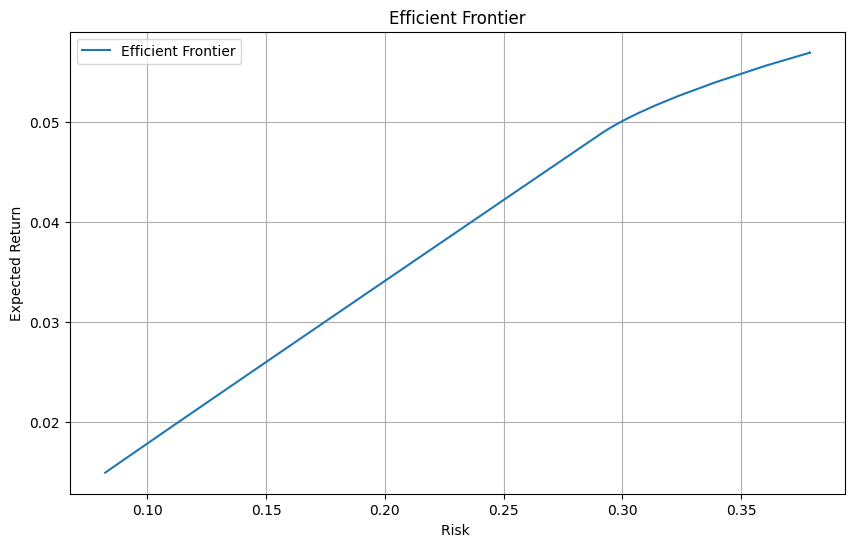

In [58]:
import matplotlib.pyplot as plt

risk_values = []
return_values = []

#for different risk levels , doing optimizations.
risk_aversion_levels = np.linspace(0, 1, 50)  # 0 to 1 with 50 steps
for risk_aversion in risk_aversion_levels:
    problem = cp.Problem(cp.Maximize(ret - risk_aversion * risk), 
                         [cp.sum(w) == 1, w >= 0])
    problem.solve()
    optimal_w = w.value
    
    # Calculated expected return and risk values.
    portfolio_return = mu @ optimal_w
    portfolio_risk = np.sqrt(optimal_w.T @ cov_matrix.values @ optimal_w)
    
    return_values.append(portfolio_return)
    risk_values.append(portfolio_risk)

# Efficient Frontier 
plt.figure(figsize=(10, 6))
plt.plot(risk_values, return_values, label='Efficient Frontier')
plt.xlabel('Risk ')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()


In [59]:
# interest rate without risk (for example, 3%)
risk_free_rate = 0.03

# Sharpe ratio 
sharpe_ratio = (expected_return - risk_free_rate) / expected_risk
print(f"Sharpe ratio: {sharpe_ratio:.4f}")


Sharpe ratio: -0.0126


In [ ]:
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env
#Based on OpenAI Gym we create special porfolioEnv class. 
class PortfolioEnv(gym.Env):
    def __init__(self, returns):
        super(PortfolioEnv, self).__init__()
        self.returns = returns
        self.num_assets = returns.shape[1]
        self.current_step = 0
        
        # Action and observation spaces determined.
        self.action_space = spaces.Box(low=0, high=1, shape=(self.num_assets,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.num_assets,), dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        self.current_step = 0
        return self.returns.iloc[self.current_step].values.astype(np.float32), {}
        
    def step(self, action):
        self.current_step += 1
        
        # Normalized actions (Sum of all weights should be 1)
        weights = action / np.sum(action) if np.sum(action) > 0 else np.ones_like(action) / len(action)
        
        # Portfolio return calculated
        portfolio_return = np.dot(weights, self.returns.iloc[self.current_step].values)
        
        # based on return, calculated reward (Prevent NaN formation by scaling.)
        reward = np.clip(portfolio_return, -1, 1)
        
        # next Observation state
        next_state = self.returns.iloc[self.current_step].values.astype(np.float32)
        
        # Is it completed Episode
        terminated = self.current_step >= len(self.returns) - 1  # End of dataset it is true
        truncated = False  # There is no time limit , So it is False
        
        return next_state, reward, terminated, truncated, {}


In [60]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_checker import check_env

# Initialize environment and check it
env = PortfolioEnv(returns)
check_env(env)

# Define and train PPO model
model = PPO('MlpPolicy', env, verbose=1)
model.learn(total_timesteps=10000)


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\stable_baselines3\common\env_checker.py:462: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.51e+03 |
|    ep_rew_mean     | 18.2     |
| time/              |          |
|    fps             | 1223     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 1.51e+03    |
|    ep_rew_mean          | 15.2        |
| time/                   |             |
|    fps                  | 894         |
|    iterations           | 2           |
|    time_elapsed         | 4           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009601193 |
|    clip_fraction        | 0.0663      |
|    clip_range           | 0.2         |
|    entropy_loss   

In [61]:
# 5. Testing the Model
state, _ = env.reset()
done = False
total_reward = 0

while not done:
    action, _ = model.predict(state)
    state, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    done = terminated or truncated

print("Total Reward:", total_reward)


Total Reward: 18.555125985828816


In [62]:
import matplotlib.pyplot as plt

# 1. Cumulative Return 
state, _ = env.reset()
done = False
cumulative_returns = [1]  # initial value is 1

while not done:
    action, _ = model.predict(state)
    state, reward, terminated, truncated, _ = env.step(action)
    cumulative_returns.append(cumulative_returns[-1] * (1 + reward))
    done = terminated or truncated

In [65]:
#Analyzed the model's performance over time by calculating its cumulative returns.
#Compared the model's performance with an equally weighted benchmark.
equal_weights = np.ones(env.num_assets) / env.num_assets
benchmark_returns = (returns @ equal_weights).cumsum()
print(benchmark_returns)


Date
2018-01-03     0.028631
2018-01-04    -0.003419
2018-01-05     0.022913
2018-01-08     0.000951
2018-01-09     0.002650
                ...    
2023-12-22    15.475783
2023-12-26    15.419708
2023-12-27    15.483639
2023-12-28    15.451316
2023-12-29    15.497297
Length: 1508, dtype: float64
